In [29]:
#install.packages(c("dplyr", "ggplot2", "readr", "stringr"))

library(dplyr)
library(ggplot2)
library(readr)
library(stringr)

In [30]:
# -------------------------------------------------------------------
# 1) Carregar o CSV
# -------------------------------------------------------------------
dados <- read_csv("phase3/output/2025-11-20_17-48-37/benchmark_results_2025-11-20_20-48-41_fixed.csv")

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)"
Rows: 300 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): algorithm, filename
dbl (20): run, comp_time_ms, decomp_time_ms, orig_size_b, compressed_size_b,...
num  (1): decomp_write_calls

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [31]:
# -------------------------------------------------------------------
# 2) EXTRAI O TAMANHO DO ARQUIVO (1M a 25M) DO FILENAME
# -------------------------------------------------------------------
dados <- dados %>%
  mutate(
    tamanho = as.numeric(str_extract(filename, "(?<=testfile_)(\\d+)(?=M)")),
    comp_time_sec = comp_time_ms / 1000,
    decomp_time_sec = decomp_time_ms / 1000
  )

In [32]:
# -------------------------------------------------------------------
# 3) CALCULA MÉDIAS POR ALGORITMO E TAMANHO
# -------------------------------------------------------------------
resumo <- dados %>%
  group_by(algorithm, tamanho) %>%
  summarise(
    media_comp = mean(comp_time_sec),
    media_decomp = mean(decomp_time_sec),
    media_ratio = mean(compression_ratio_pct),
    .groups = "drop"
  )

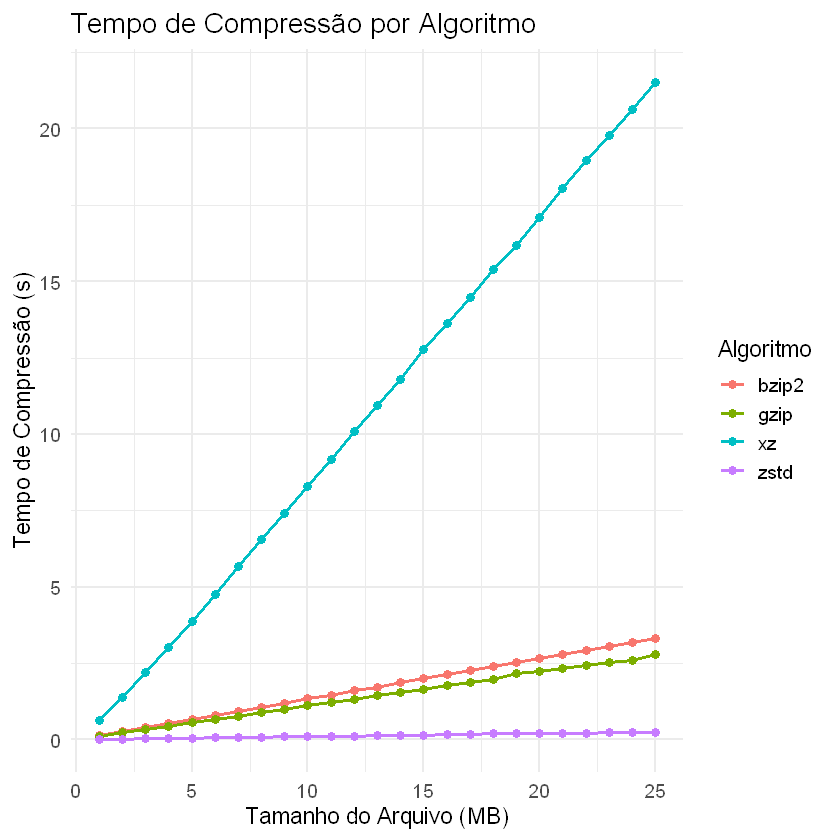

In [33]:
# -------------------------------------------------------------------
# 4) GRÁFICO 1 — TEMPO DE COMPRESSÃO
# -------------------------------------------------------------------
grafico_comp <- ggplot(resumo, aes(
  x = tamanho,
  y = media_comp,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Tempo de Compressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Compressão (s)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_comp)

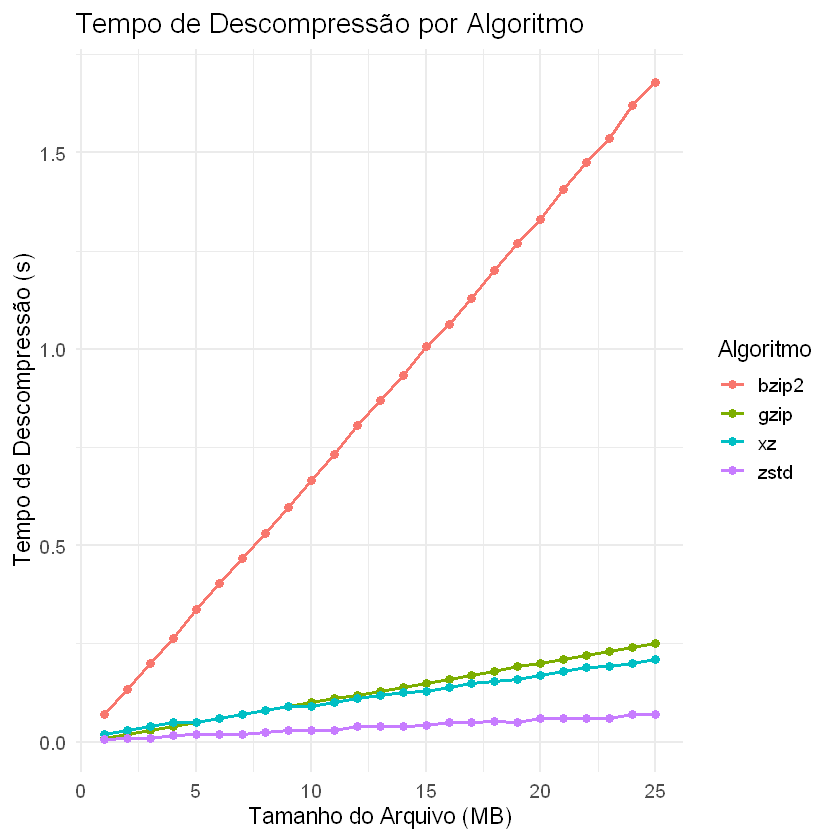

In [34]:
# -------------------------------------------------------------------
# 5) GRÁFICO 2 — TEMPO DE DESCOMPRESSÃO
# -------------------------------------------------------------------
grafico_decomp <- ggplot(resumo, aes(
  x = tamanho,
  y = media_decomp,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Tempo de Descompressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Tempo de Descompressão (s)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_decomp)

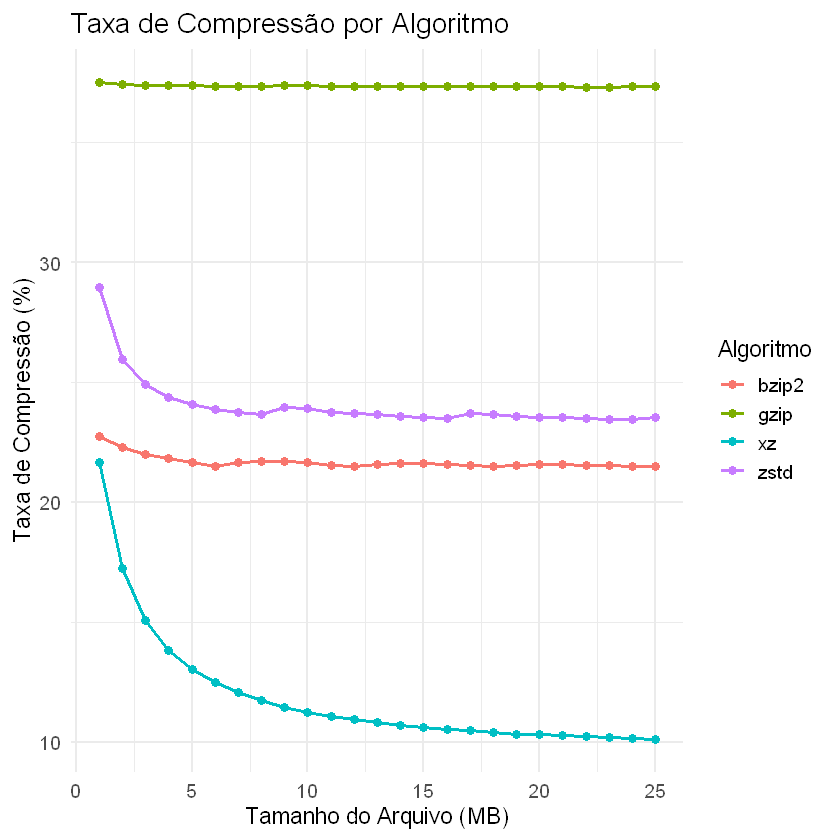

In [35]:
# -------------------------------------------------------------------
# 6) GRÁFICO 3 — TAXA DE COMPRESSÃO (PERCENTUAL)
# -------------------------------------------------------------------
grafico_ratio <- ggplot(resumo, aes(
  x = tamanho,
  y = media_ratio,
  color = algorithm,
  group = algorithm
)) +
  geom_line(size = 1) +
  geom_point(size = 2) +
  labs(
    title = "Taxa de Compressão por Algoritmo",
    x = "Tamanho do Arquivo (MB)",
    y = "Taxa de Compressão (%)",
    color = "Algoritmo"
  ) +
  theme_minimal(base_size = 14)

print(grafico_ratio)

In [36]:
# -------------------------------------------------------------------
# 7) BAIXAR OS GRÁFICOS
# -------------------------------------------------------------------
ggsave("./graphs/phase3/comp_time.png", grafico_comp, width = 8, height = 5)
ggsave("./graphs/phase3/decomp_time.png", grafico_decomp, width = 8, height = 5)
ggsave("./graphs/phase3/comp_ratio.png", grafico_ratio, width = 8, height = 5)